In [1]:
import pandas as pd
import numpy as np

In [255]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')

In [256]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [257]:
df.describe()

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
count,10000.000000,10000.00000,10000.000000,10000.000000,9123.000000,10000.000000,9736.000000,10000.000000
mean,1999.549500,3.50400,2268.807000,6.035200,254.446016,4286.754000,18.888044,29.997700
std,14.207925,0.95209,183.447355,0.542578,22.844613,266.212491,1.279543,2.930245
min,1975.000000,2.00000,1590.000000,4.000000,171.000000,3320.000000,14.000000,19.800000
25%,1987.000000,3.00000,2150.000000,6.000000,239.000000,4110.000000,18.000000,28.000000
50%,2000.000000,4.00000,2270.000000,6.000000,254.000000,4280.000000,18.900000,30.000000
75%,2012.000000,4.00000,2390.000000,6.000000,270.000000,4470.000000,19.700000,31.900000
max,2024.000000,5.00000,3110.000000,8.000000,334.000000,5460.000000,23.800000,41.200000


In [258]:
df_subset = df[
    ['engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg']
]

In [259]:
df_subset.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [260]:
df_subset.describe().round(2)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.00,9123.00,10000.00,10000.00,10000.00
mean,2268.81,254.45,4286.75,1999.55,30.00
std,183.45,22.84,266.21,14.21,2.93
min,1590.00,171.00,3320.00,1975.00,19.80
25%,2150.00,239.00,4110.00,1987.00,28.00
50%,2270.00,254.00,4280.00,2000.00,30.00
75%,2390.00,270.00,4470.00,2012.00,31.90
max,3110.00,334.00,5460.00,2024.00,41.20


## EDA

<AxesSubplot:xlabel='fuel_efficiency_mpg', ylabel='Count'>

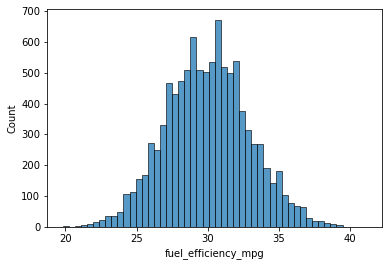

In [13]:
import matplotlib as plt
import seaborn as sns

%matplotlib inline 

sns.histplot(df_subset['fuel_efficiency_mpg'], bins=50)

### fuel_efficiency_mpg variable does not have a long tail.

## Question 1

In [18]:
#Q1: There's one column with missing values. What is it?

In [19]:
df_subset.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [20]:
# Ans: horsepower has missing values. 

## Question 2

In [23]:
# Q2: What's the median (50% percentile) for variable 'horsepower'?

In [254]:
df_subset['horsepower'].describe()

count    10000.000000
mean       232.131100
std         75.210419
min          0.000000
25%        234.000000
50%        252.000000
75%        268.000000
max        334.000000
Name: horsepower, dtype: float64

In [26]:
# Ans: 254

## Question 3

## Prepare and split the dataset

In [30]:
# Shuffle the filtered dataset and create the split exactly as in the lecture:

# n = len(df)
# n_val = int(n * 0.2)
# n_test = int(n * 0.2)
# n_train = n - n_val - n_test

# np.random.seed(42)
# idx = np.arange(n)
# np.random.shuffle(idx)

# df_train = df.iloc[idx[:n_train]]
# df_val = df.iloc[idx[n_train:n_train + n_val]]
# df_test = df.iloc[idx[n_train + n_val:]]

In [64]:
n = len(df_subset)

n_train = int(n * 0.6)
n_val = int(n * 0.2)
n_val = int(n * 0.2)
n_train, n_val, n_val

(6000, 2000, 2000)

In [65]:
df_subset.iloc[:10]

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
5,2290,266.0,4260,2007,31.2
6,2270,250.0,4310,1992,26.8
7,2370,279.0,4090,2005,30.2
8,2330,251.0,4230,1997,30.9
9,2330,280.0,4620,2004,31.2


In [66]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
idx

array([6252, 4684, 1731, ..., 5390,  860, 7270])

In [68]:
df_train = df_subset.iloc[idx[:n_train]]
df_val = df_subset.iloc[idx[n_train:n_train+n_val]]
df_test = df_subset.iloc[idx[n_train+n_val:]]

n, len(df_train), len(df_val), len(df_test)

(10000, 6000, 2000, 2000)

In [267]:
def split_df(df, seed):
    n = len(df)

    n_train = int(n * 0.6)
    n_val = int(n * 0.2)
    n_val = int(n * 0.2)

    np.random.seed(seed)
    idx = np.arange(len(df))
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    return df_train, df_val, df_test

In [91]:
df_train, df_val, df_test = split_df(df_subset, 42)
n, len(df_train), len(df_val), len(df_test)

(10000, 6000, 2000, 2000)

### Option#1 Fill with Zeros

In [75]:
df_subset['fuel_efficiency_mpg'].isnull().sum()

0

In [84]:
df_subset.describe().round(2)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.00,9123.00,10000.00,10000.00,10000.00
mean,2268.81,254.45,4286.75,1999.55,30.00
std,183.45,22.84,266.21,14.21,2.93
min,1590.00,171.00,3320.00,1975.00,19.80
25%,2150.00,239.00,4110.00,1987.00,28.00
50%,2270.00,254.00,4280.00,2000.00,30.00
75%,2390.00,270.00,4470.00,2012.00,31.90
max,3110.00,334.00,5460.00,2024.00,41.20


In [85]:
df_subset['horsepower'].isnull().sum()

877

In [88]:
# Fill null with zeros
df_subset['horsepower'].fillna(0)

0       243.0
1       272.0
2       267.0
3       258.0
4       304.0
        ...  
9995    271.0
9996    244.0
9997    267.0
9998    270.0
9999    295.0
Name: horsepower, Length: 10000, dtype: float64

In [89]:
df_subset['horsepower'].isnull().sum()

0

In [280]:
df_subset['horsepower']

0       243.0
1       272.0
2       267.0
3       258.0
4       304.0
        ...  
9995    271.0
9996    244.0
9997    267.0
9998    270.0
9999    295.0
Name: horsepower, Length: 10000, dtype: float64

In [105]:
df_train, df_val, df_test = split_df(df_subset, 42)
n, len(df_train), len(df_val), len(df_test)

(10000, 6000, 2000, 2000)

In [106]:
y_train = df_train['fuel_efficiency_mpg'].values
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ])

In [107]:
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values 

In [108]:
#Remove fuel_efficiency_mpg from train datasets
del df_train['fuel_efficiency_mpg']

df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,0.0,4150,1997
4,2340,269.0,4400,2001


In [113]:
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [109]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [96]:
base = ['engine_hp','engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity' ]

In [118]:
# Train model with null values = 0
X_train = df_train.fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

In [119]:
df_val.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,2240,265.0,3990,2004
1,2390,259.0,4770,2019
2,2360,265.0,4320,2018
3,2430,279.0,4430,2008
4,2220,249.0,4030,1999


In [173]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [116]:
# use validate to get results for option 1
X_val = df_val.fillna(0).values

y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

2.20529319475358

In [121]:
rmse(y_val, y_pred).round(3)

2.205

### RMSE with null values = 2.205

In [120]:
# Train model with null values as mean
train_mean = df_train.mean()

X_train = df_train.fillna(train_mean).values

w0, w = train_linear_regression(X_train, y_train)

In [122]:
# use validate to get results for option 2
val_mean = df_val.mean()
X_val = df_val.fillna(val_mean).values

y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

2.20529319475358

In [123]:
rmse(y_val, y_pred).round(3)

2.205

### RMSE with null mean = 2.205

### Ans 3: Both are equally good

## Question 4

In [131]:
# Now let's train a regularized linear regression.
# For this question, fill the NAs with 0.
# Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
# Use RMSE to evaluate the model on the validation dataset.
# Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
# Which r gives the best RMSE?
# If multiple options give the same best RMSE, select the smallest r

## Regularized LR training

In [265]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [136]:
r = [0, 0.01, 0.1, 1, 5, 10, 100]

In [153]:
def train_reg(X_train, y_train, r=0):
    #X_train = X_train.fillna(0).values

    w0, w = train_linear_regression_reg(X_train, y_train, r)

    X_val = df_val.fillna(0).values

    y_pred = w0 + X_val.dot(w)

    rmse(y_val, y_pred)
    print('RMSE with ',r, rmse(y_val, y_pred).round(4))
    
    return

In [199]:
RMSE=[]

In [200]:
X_train = df_train.fillna(0).values
w0, w = train_linear_regression_reg(X_train, y_train, r=0)

X_val = df_val.fillna(val_mean).values
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

print('RMSE with r=','0', rmse(y_val, y_pred).round(4))

RMSE.append(rmse(y_val, y_pred).round(4))

RMSE with r= 0 2.2053


In [201]:
X_train = df_train.fillna(0).values
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = df_val.fillna(val_mean).values
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

print('RMSE with r=','0.01', rmse(y_val, y_pred).round(4))
RMSE.append(rmse(y_val, y_pred).round(4))

RMSE with r= 0.01 2.2058


In [202]:
X_train = df_train.fillna(0).values
w0, w = train_linear_regression_reg(X_train, y_train, r=0.1)

X_val = df_val.fillna(val_mean).values
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

print('RMSE with r=','0.1', rmse(y_val, y_pred).round(4))
RMSE.append(rmse(y_val, y_pred).round(4))

RMSE with r= 0.1 2.2241


In [203]:
X_train = df_train.fillna(0).values
w0, w = train_linear_regression_reg(X_train, y_train, r=1)

X_val = df_val.fillna(val_mean).values
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

print('RMSE with r=','1', rmse(y_val, y_pred).round(4))
RMSE.append(rmse(y_val, y_pred).round(4))

RMSE with r= 1 2.3492


In [204]:
X_train = df_train.fillna(0).values
w0, w = train_linear_regression_reg(X_train, y_train, r=5)

X_val = df_val.fillna(val_mean).values
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

print('RMSE with r=','5', rmse(y_val, y_pred).round(4))
RMSE.append(rmse(y_val, y_pred).round(4))

RMSE with r= 5 2.4094


In [205]:
X_train = df_train.fillna(0).values
w0, w = train_linear_regression_reg(X_train, y_train, r=10)

X_val = df_val.fillna(val_mean).values
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

print('RMSE with r=','10', rmse(y_val, y_pred).round(4))
RMSE.append(rmse(y_val, y_pred).round(4))

RMSE with r= 10 2.4195


In [206]:
X_train = df_train.fillna(0).values
w0, w = train_linear_regression_reg(X_train, y_train, r=100)

X_val = df_val.fillna(val_mean).values
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

print('RMSE with r=','100', rmse(y_val, y_pred).round(4))
RMSE.append(rmse(y_val, y_pred).round(4))

RMSE with r= 100 2.4292


In [207]:
RMSE

[2.2053, 2.2058, 2.2241, 2.3492, 2.4094, 2.4195, 2.4292]

In [208]:
min(RMSE)

2.2053

## Ans: Least RMSE=2.2053 with r=0

## Question 5

In [212]:
# We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
# Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
# For each seed, do the train/validation/test split with 60%/20%/20% distribution.
# Fill the missing values with 0 and train a model without regularization.
# For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
# What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
# Round the result to 3 decimal digits (round(std, 3))

In [279]:
def split_df_new(df, seed):
    n = len(df)

    n_train = int(n * 0.6)
    n_val = int(n * 0.2)
    n_val = int(n * 0.2)

    np.random.seed(seed)
    idx = np.arange(len(df))
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values 
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    
    return df_train, df_val, df_test, y_train, y_val, y_test

In [231]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [232]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [233]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [237]:
result = []

for i in seed:
    df_train, df_val, df_test, y_train, y_val, y_test = split_df(df_subset, i)
    
    X_train = df_train.fillna(0).values
    
    w0, w = train_linear_regression(X_train, y_train)

    X_val = df_val.fillna(0).values

    y_pred = w0 + X_val.dot(w)

    result.append(rmse(y_val, y_pred))


In [238]:
result

[2.2392041430552805,
 2.202112821083947,
 2.1634197787531013,
 2.2043588768533255,
 2.201880094330643,
 2.2457851509078637,
 2.269721207950886,
 2.1907945999367575,
 2.2166112016940303,
 2.207036592830149]

In [240]:
std_dev = np.std(result).round(3)
std_dev

0.029

### Ans 5: Standard deviation=0.029

## Question 6

In [245]:
# Split the dataset like previously, use seed 9.
# Combine train and validation datasets.
# Fill the missing values with 0 and train a model with r=0.001.
# What's the RMSE on the test dataset?

In [281]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

In [282]:
X_full_train = df_full_train.fillna(0).values
X_full_train.shape

(8000, 4)

In [283]:
y_full_train = np.concatenate([y_train, y_val])
y_full_train.shape

(8000,)

In [284]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
w.shape

(4,)

In [285]:
X_test = df_test.fillna(0).values

y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

In [286]:
score

2.2358277471948154

## Answer: 2.23